In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [12]:
df = pd.read_csv("./cleaned_COVID_data.csv")
df_models = pd.read_csv("./cleaned_COVID_data_models_both.csv")
df_pos = pd.read_csv("./cleaned_COVID_data_POS.csv")
df_neg = pd.read_csv("./cleaned_COVID_data_NEG.csv")

C:\Users\glaro\AppData\Local\Temp\ipykernel_41848\1829303037.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./cleaned_COVID_data.csv")


In [13]:
df.shape,df_models.shape, df_pos.shape, df_neg.shape    

((236530, 24), (236530, 16), (113289, 16), (123241, 16))

In [14]:
df.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU,COVID_POSITIVE,DIED,ID
0,2,4,1,2,2020-01-02,2,2,65,2,2,...,2,2,2,2,2,7,2,2,1,1
1,1,12,2,2,2020-01-03,1,1,47,2,2,...,2,2,2,2,2,5,1,2,1,2
2,1,4,2,2,2020-01-03,2,2,32,2,2,...,2,2,2,2,2,7,2,2,1,3
3,1,4,1,2,2020-01-03,2,2,67,2,1,...,2,2,1,2,2,7,2,2,1,4
4,1,4,2,2,2020-01-03,2,2,15,2,2,...,2,2,2,2,2,7,2,2,1,5


# STATISTICS

## 1. AGE DISTRIBUTION

### 1.1 COMPLETE POPULATION

In [15]:
df['AGE'].describe()

count    236530.000000
mean         52.620031
std          19.318158
min           0.000000
25%          40.000000
50%          54.000000
75%          67.000000
max         120.000000
Name: AGE, dtype: float64

In [16]:
df['AGE'].skew()

-0.3219846222566401

In [17]:
df['AGE'].kurt()

-0.19282908267821863

The age distribution in the complete population is broad and centered around middle age (median 54 years). The distribution is approximately symmetric (skew −0.32) with slightly light tails (kurtosis −0.19), indicating no extreme outliers or heavy‑tailed behavior. Overall, AGE shows a stable, well‑behaved distribution suitable for downstream modeling without transformation.

In [18]:
from scipy.stats import kstest, norm

# Standardisieren
age = df['AGE'].dropna()
age_std = (age - age.mean()) / age.std()

kstest(age_std, 'norm')


KstestResult(statistic=0.037310306554374506, pvalue=1.6111286538561677e-286, statistic_location=0.17496330151076475, statistic_sign=-1)

The KS test shows a statistically significant deviation from normality (D = 0.0373, p ≈ 1.6×10⁻²⁸⁶), indicating that the distribution is not perfectly normal. However, the deviation is very small in magnitude, suggesting that the data are only mildly non‑normal despite the extremely large sample size making the test highly sensitive.

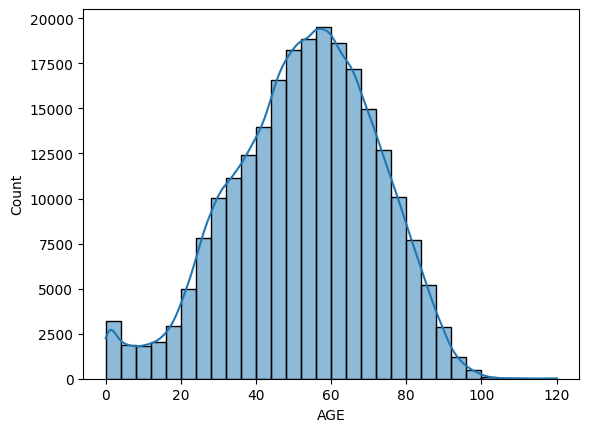

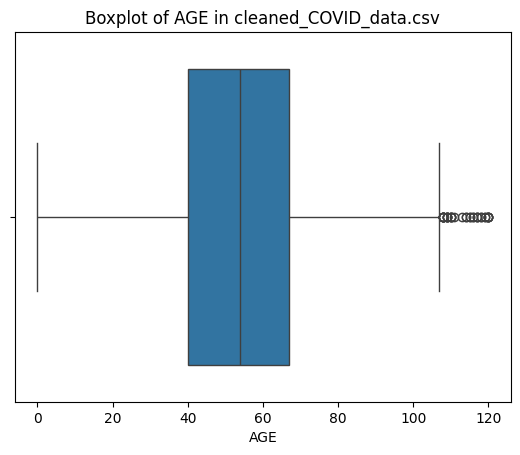

In [20]:
sns.histplot(df['AGE'], kde=True, bins=30)
plt.show()

sns.boxplot(x=df['AGE'])
plt.title("Boxplot of AGE in cleaned_COVID_data.csv")
plt.show()

The age distribution is broadly bell‑shaped with a median around 55–60 years. A small number of newborns (age 0) are present and treated as valid observations. The range extends up to centenarians, with only a few high‑age outliers.

In [21]:
df[df['AGE'] == 0].shape

(1059, 24)

## 1.2 ONLY COVID POS

In [28]:
df_pos['AGE'].describe()

count    113289.000000
mean         55.474027
std          17.316269
min           0.000000
25%          44.000000
50%          57.000000
75%          68.000000
max         120.000000
Name: AGE, dtype: float64

In [29]:
df_pos['AGE'].skew()

-0.3512515296231362

In [30]:
df_pos['AGE'].kurt()

-0.03890348373647923

In [31]:
from scipy.stats import kstest, norm

# Standardisieren
age = df_pos['AGE'].dropna()
age_std = (age - age.mean()) / age.std()

kstest(age_std, 'norm')

KstestResult(statistic=0.038230445304901994, pvalue=2.6485010598369486e-144, statistic_location=0.030374522252544472, statistic_sign=-1)

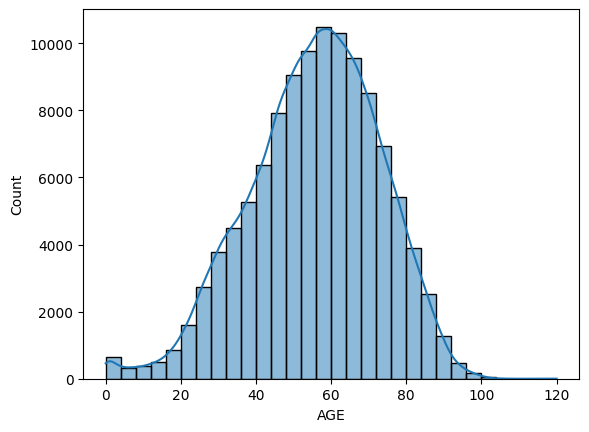

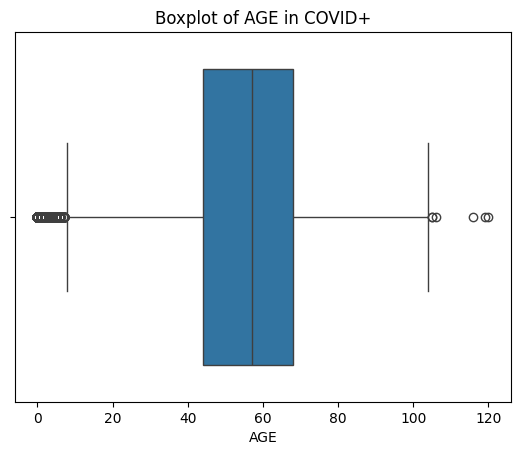

In [32]:
sns.histplot(df_pos['AGE'], kde=True, bins=30)
plt.show()

sns.boxplot(x=df_pos['AGE'])
plt.title("Boxplot of AGE in COVID+")
plt.show()

Among COVID‑positive patients, the age distribution is roughly bell‑shaped with a peak around 60 years. A few newborns (age 0) are present and treated as valid cases, while the upper range includes several centenarians. Overall, the distribution shows a predominantly older adult population with a wide age span and some extreme values at both ends.

## 1.3 ONLY COVID NEG

In [48]:
df_neg['AGE'].describe()

count    123241.000000
mean         49.996503
std          20.645568
min           0.000000
25%          36.000000
50%          51.000000
75%          65.000000
max         120.000000
Name: AGE, dtype: float64

In [49]:
df_neg['AGE'].skew()

-0.2030959955975713

In [50]:
df_neg['AGE'].kurt()

-0.3864950818527024

In [52]:
from scipy.stats import kstest, norm

# Standardisieren
age = df_neg['AGE'].dropna()
age_std = (age - age.mean()) / age.std()

kstest(age_std, 'norm')

KstestResult(statistic=0.028759697176546695, pvalue=5.4558289728506646e-89, statistic_location=0.24235211678896282, statistic_sign=-1)

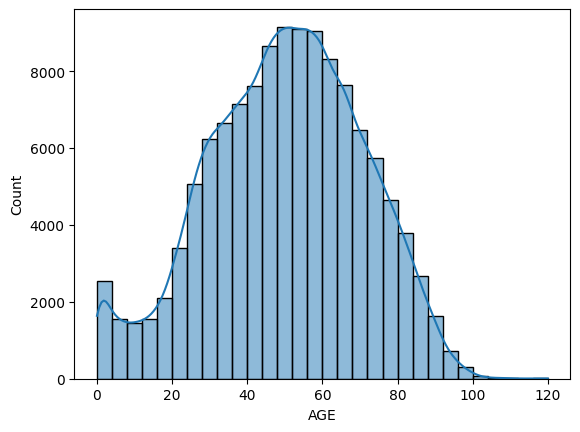

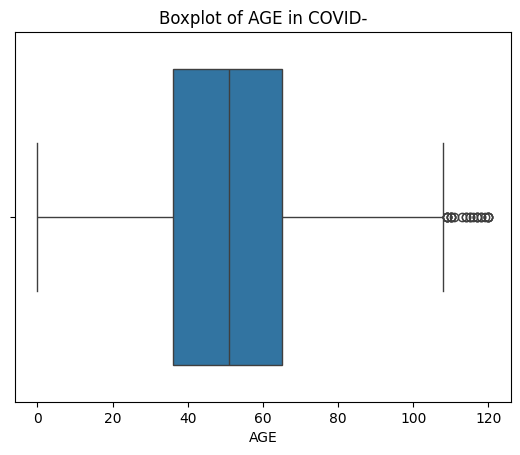

In [53]:
sns.histplot(df_neg['AGE'], kde=True, bins=30)
plt.show()

sns.boxplot(x=df_neg['AGE'])
plt.title("Boxplot of AGE in COVID-")
plt.show()

Among COVID‑negative patients, the age distribution is broadly bell‑shaped with most individuals between 40 and 70 years and a median around the mid‑50s. A few newborns (age 0) appear as valid observations, and several very old individuals (>100 years) form the upper outliers. Overall, the distribution reflects a predominantly middle‑to‑older adult population with a wide but stable age spread.

## 1.4 DIFFERENCE IN MORTALITY RATE 

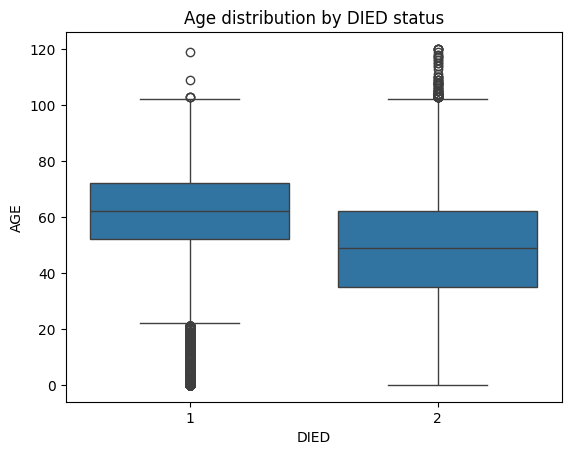

MannwhitneyuResult(statistic=3744677705.5, pvalue=0.0)

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

sns.boxplot(x='DIED', y='AGE', data=df)
plt.title('Age distribution by DIED status')
plt.show()

alive = df[df['DIED'] == 2]['AGE']
dead  = df[df['DIED'] == 1]['AGE']
mannwhitneyu(alive, dead, alternative='two-sided')


Age differs significantly between the two DIED groups. Patients who died are generally older, with a higher median age and a broader spread toward advanced ages. Survivors are noticeably younger on average. The Mann–Whitney U test confirms this difference is statistically significant (p < 0.001).

In [76]:
from scipy.stats import ttest_ind

died = df[df['DIED'] == 1]['AGE'].dropna()
alive = df[df['DIED'] == 2]['AGE'].dropna()

t_stat, p_val = ttest_ind(died, alive, equal_var=False)
print( 't_stat:', t_stat )
print( 'p_val:', p_val )


t_stat: 167.03777010271068
p_val: 0.0


In [77]:
died.mean(), alive.mean()

(61.06216020535773, 48.62597079064553)

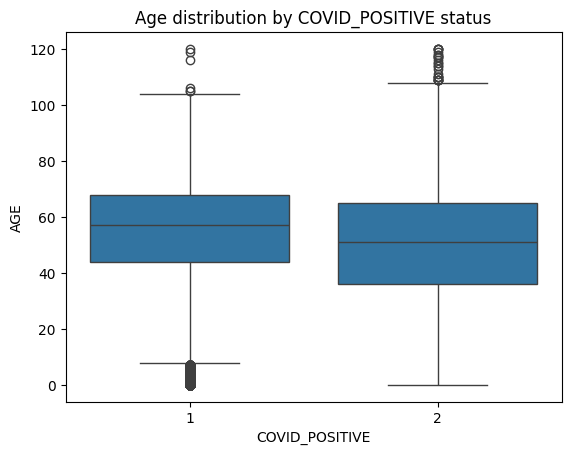

MannwhitneyuResult(statistic=8071823072.0, pvalue=0.0)

In [59]:
sns.boxplot(x='COVID_POSITIVE', y='AGE', data=df)
plt.title('Age distribution by COVID_POSITIVE status')
plt.show()

pos = df[df['COVID_POSITIVE'] == 1]['AGE']
neg  = df[df['COVID_POSITIVE'] == 2]['AGE']
mannwhitneyu(pos, neg, alternative='two-sided')

Age differs significantly between COVID‑positive and COVID‑negative individuals. COVID‑positive patients tend to be older on average, with a higher median age and a broader spread toward advanced ages. COVID‑negative individuals are comparatively younger. The Mann–Whitney U test confirms that this difference is statistically significant (p < 0.001).

# 2. FEATURE INTERACTIONS

## 2.1 LABEL DIED

In [64]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

nominal_vars = [
    'SEX','PATIENT_TYPE','INTUBED','PNEUMONIA','PREGNANT','DIABETES','COPD',
    'ASTHMA','INMSUPR','HIPERTENSION','OTHER_DISEASE','CARDIOVASCULAR',
    'OBESITY','RENAL_CHRONIC','USMER','TOBACCO', 'ICU','COVID_POSITIVE','MEDICAL_UNIT'
]

target = 'DIED'

results = []
for var in nominal_vars:
    ct = pd.crosstab(df[var], df[target])
    if ct.shape[0] > 1 and ct.shape[1] > 1:  
        cv = cramers_v(ct)
        results.append((var, cv))

cramers_died = pd.DataFrame(results, columns=['Variable','CramersV']).sort_values('CramersV', ascending=False)
print(cramers_died)


          Variable  CramersV
1     PATIENT_TYPE  0.462464
2          INTUBED  0.413637
3        PNEUMONIA  0.386513
17  COVID_POSITIVE  0.307460
18    MEDICAL_UNIT  0.233584
7           ASTHMA  0.132171
0              SEX  0.130168
16             ICU  0.118384
15         TOBACCO  0.103637
14           USMER  0.098136
5         DIABETES  0.085724
4         PREGNANT  0.071005
9     HIPERTENSION  0.066978
12         OBESITY  0.063438
10   OTHER_DISEASE  0.057337
8          INMSUPR  0.054243
11  CARDIOVASCULAR  0.045139
6             COPD  0.019101
13   RENAL_CHRONIC  0.007247


Cramér’s V quantifies the strength of association between two categorical variables, ranging from 0 (no association) to 1 (perfect association). The strongest associations with the outcome are observed for PATIENT_TYPE, INTUBED, and PNEUMONIA, indicating that acute clinical severity markers are most strongly linked to the target variable. COVID_POSITIVE and MEDICAL_UNIT show moderate associations, while comorbidities such as asthma, diabetes, hypertension, obesity, and cardiovascular disease exhibit only weak relationships. RENAL_CHRONIC and COPD show almost no association. 

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v1(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

nominal_vars = [
    'MEDICAL_UNIT','SEX','PATIENT_TYPE','INTUBED','PNEUMONIA','PREGNANT',
    'DIABETES','COPD','ASTHMA','INMSUPR','HIPERTENSION','OTHER_DISEASE',
    'CARDIOVASCULAR','OBESITY','RENAL_CHRONIC','USMER','TOBACCO',
    'ICU','COVID_POSITIVE','DIED'
]

# Matrix
matrixV1 = pd.DataFrame(np.zeros((len(nominal_vars), len(nominal_vars))),
                      index=nominal_vars, columns=nominal_vars)

for col1 in nominal_vars:
    for col2 in nominal_vars:
        ct = pd.crosstab(df[col1], df[col2])
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            matrixV1.loc[col1, col2] = cramers_v1(ct)
        else:
            matrixV1.loc[col1, col2] = 0 


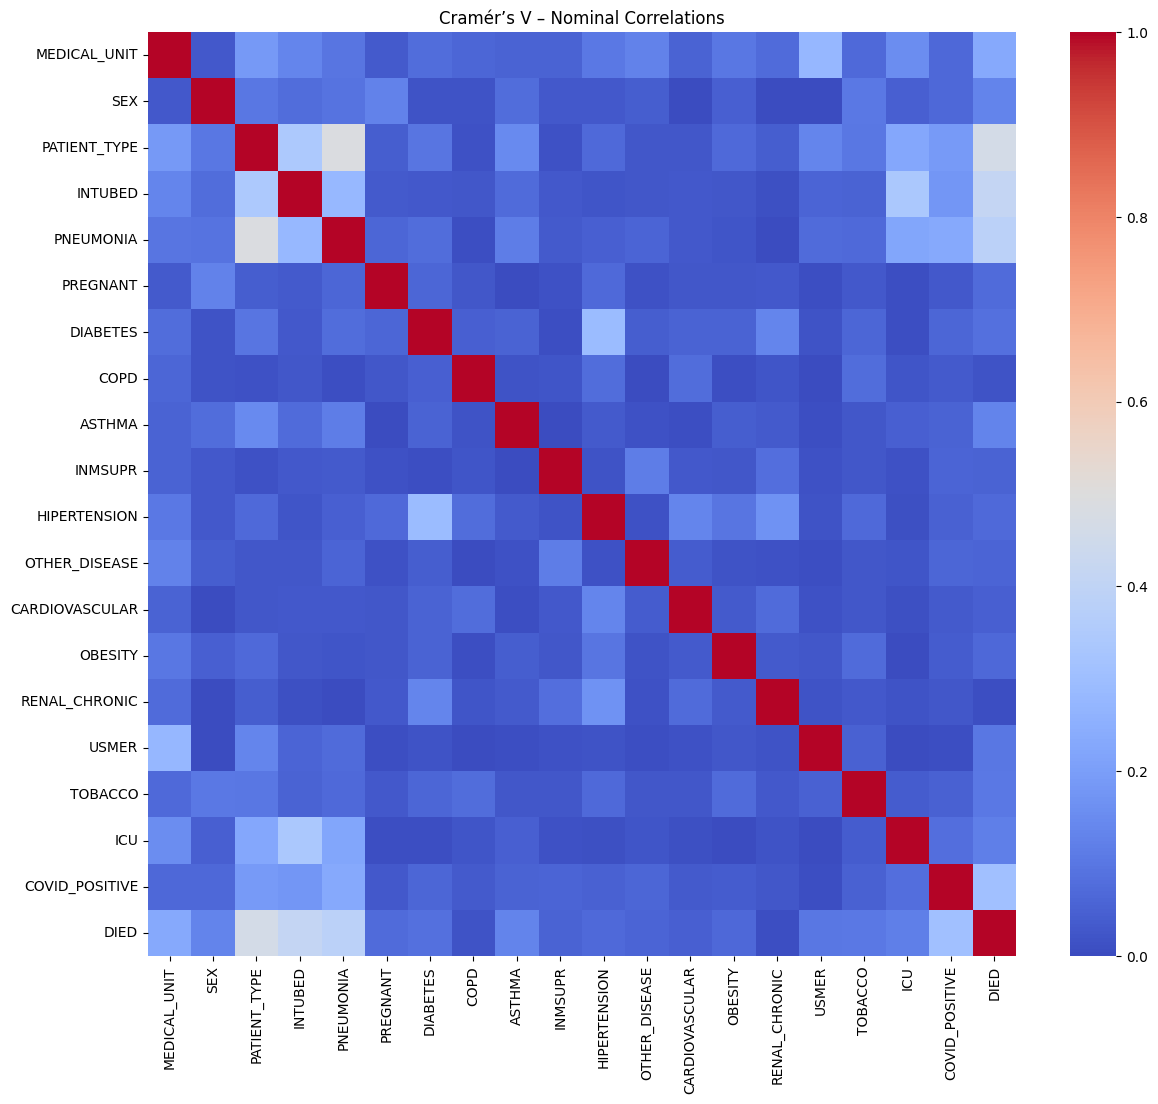

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,12))
sns.heatmap(matrixV1, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér’s V – Nominal Correlations")
plt.show()


The Cramér’s V heatmap shows that most categorical variables have only weak associations with one another, indicating low multicollinearity across the dataset. Stronger relationships appear mainly among clinically related variables such as INTUBED, PNEUMONIA, PATIENT_TYPE, ICU, and DIED, reflecting their shared link to disease severity. COVID_POSITIVE also shows a strong association with several severity markers. Overall, the heatmap confirms that most predictors are only loosely correlated, supporting their suitability for downstream modeling.

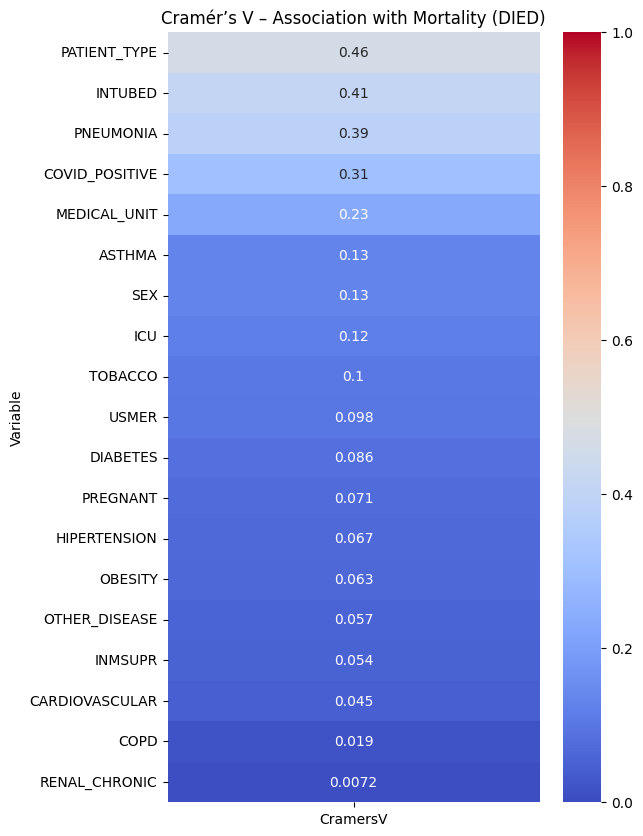

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = cramers_died.set_index('Variable')

plt.figure(figsize=(6,10))
sns.heatmap(heatmap_df, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér’s V – Association with Mortality (DIED)")
plt.show()

Mortality shows its strongest associations with PATIENT_TYPE, INTUBED, and PNEUMONIA, indicating that acute clinical severity is the primary driver of death in this dataset. COVID_POSITIVE and MEDICAL_UNIT show moderate associations, while comorbidities such as diabetes, hypertension, obesity, COPD, and renal disease exhibit only weak links to mortality.

## 2.2 LABEL COVID_POSITIVE

In [ ]:
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

nominal_vars = [
    'SEX','PATIENT_TYPE','INTUBED','PNEUMONIA','PREGNANT','DIABETES','COPD',
    'ASTHMA','INMSUPR','HIPERTENSION','OTHER_DISEASE','CARDIOVASCULAR',
    'OBESITY','RENAL_CHRONIC','USMER','TOBACCO',
    'ICU','MEDICAL_UNIT', 'DIED'
]

target = 'COVID_POSITIVE'

results = []
for var in nominal_vars:
    ct = pd.crosstab(df[var], df[target])
    if ct.shape[0] > 1 and ct.shape[1] > 1:  
        cv = cramers_v(ct)
        results.append((var, cv))

cramers_died = pd.DataFrame(results, columns=['Variable','CramersV']).sort_values('CramersV', ascending=False)
print(cramers_died)

          Variable  CramersV
18            DIED  0.307460
3        PNEUMONIA  0.232058
1     PATIENT_TYPE  0.189148
2          INTUBED  0.178979
16             ICU  0.078478
17    MEDICAL_UNIT  0.064614
0              SEX  0.062774
10   OTHER_DISEASE  0.060001
5         DIABETES  0.059469
8          INMSUPR  0.058530
7           ASTHMA  0.054541
15         TOBACCO  0.048964
9     HIPERTENSION  0.047527
12         OBESITY  0.037057
6             COPD  0.032669
11  CARDIOVASCULAR  0.031516
4         PREGNANT  0.027587
13   RENAL_CHRONIC  0.027143
14           USMER  0.006520


COVID positivity is strongly associated with acute clinical severity markers. PNEUMONIA, PATIENT_TYPE, and INTUBED show the highest Cramér’s V values, indicating that severe respiratory involvement and the need for advanced care are the strongest correlates of being COVID‑positive. ICU admission and MEDICAL_UNIT show weaker but still meaningful associations. In contrast, chronic comorbidities such as diabetes, hypertension, obesity, COPD, and renal disease exhibit only very weak associations with COVID positivity. 

## 2.3 COVID POS DATASET

In [91]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

nominal_vars = [
    'SEX','PREGNANT','DIABETES','COPD',
    'ASTHMA','INMSUPR','HIPERTENSION','OTHER_DISEASE','CARDIOVASCULAR',
    'OBESITY','RENAL_CHRONIC','TOBACCO_1', 'TOBACCO_3','COVID_POSITIVE'
]

target = 'DIED'

results = []
for var in nominal_vars:
    ct = pd.crosstab(df_pos[var], df_pos[target])
    if ct.shape[0] > 1 and ct.shape[1] > 1:  
        cv = cramers_v(ct)
        results.append((var, cv))

cramers_died = pd.DataFrame(results, columns=['Variable','CramersV']).sort_values('CramersV', ascending=False)
print(cramers_died)


          Variable  CramersV
4           ASTHMA  0.138962
0              SEX  0.129128
11       TOBACCO_1  0.112619
1         PREGNANT  0.080634
9          OBESITY  0.078399
2         DIABETES  0.072175
6     HIPERTENSION  0.065989
7    OTHER_DISEASE  0.058847
5          INMSUPR  0.058745
8   CARDIOVASCULAR  0.050921
12       TOBACCO_3  0.023568
3             COPD  0.016615
10   RENAL_CHRONIC  0.005969


In [93]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v1(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

nominal_vars = [
   'SEX','PREGNANT','DIABETES','COPD',
    'ASTHMA','INMSUPR','HIPERTENSION','OTHER_DISEASE','CARDIOVASCULAR',
    'OBESITY','RENAL_CHRONIC','TOBACCO_1', 'TOBACCO_3','COVID_POSITIVE', 'DIED'
]

# Matrix
matrixV1 = pd.DataFrame(np.zeros((len(nominal_vars), len(nominal_vars))),
                      index=nominal_vars, columns=nominal_vars)

for col1 in nominal_vars:
    for col2 in nominal_vars:
        ct = pd.crosstab(df_pos[col1], df_pos[col2])
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            matrixV1.loc[col1, col2] = cramers_v1(ct)
        else:
            matrixV1.loc[col1, col2] = 0  


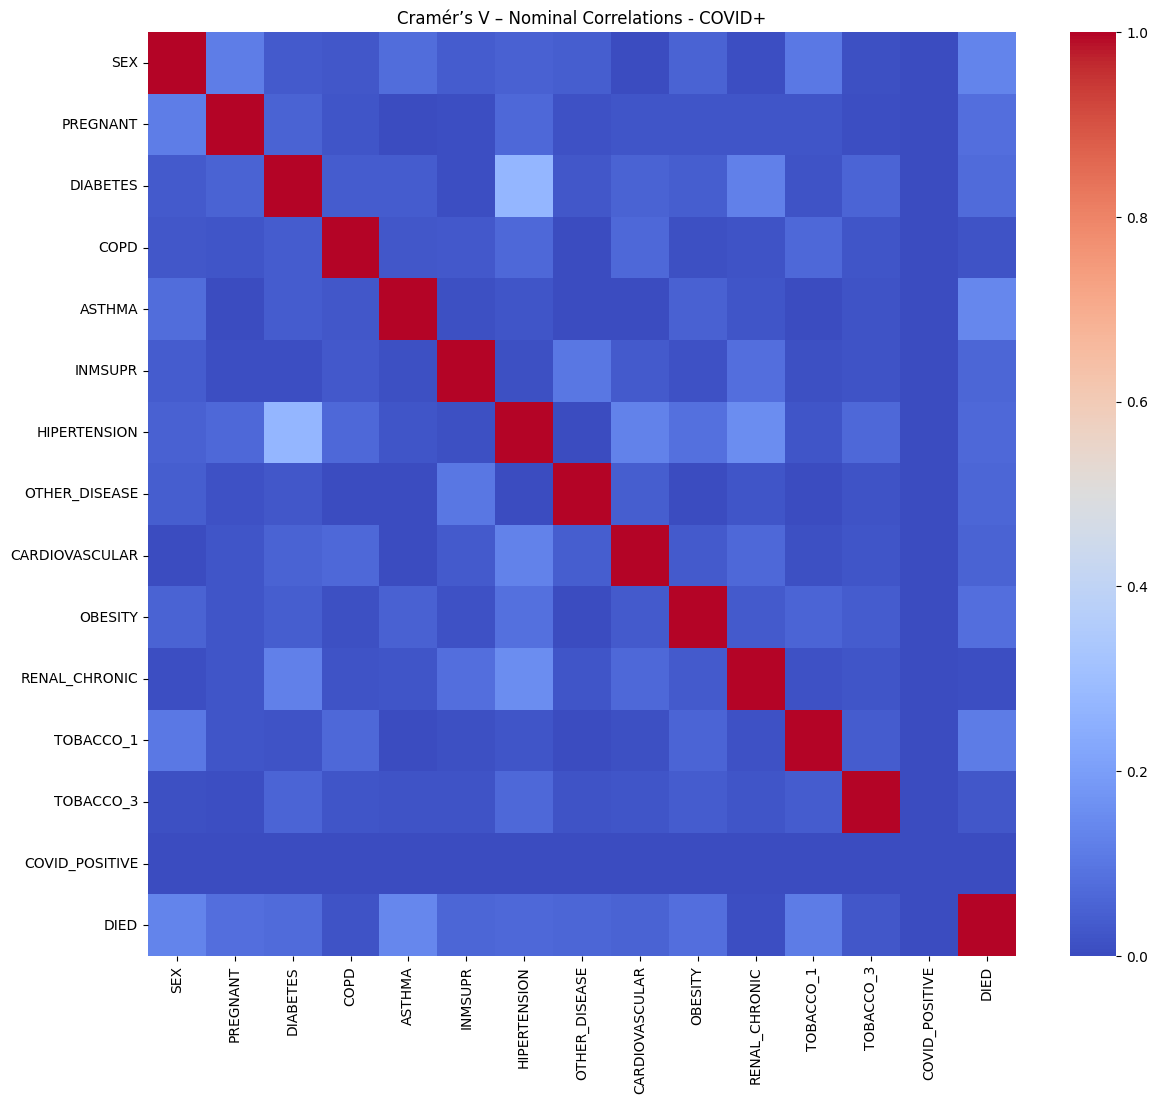

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,12))
sns.heatmap(matrixV1, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér’s V – Nominal Correlations - COVID+")
plt.show()

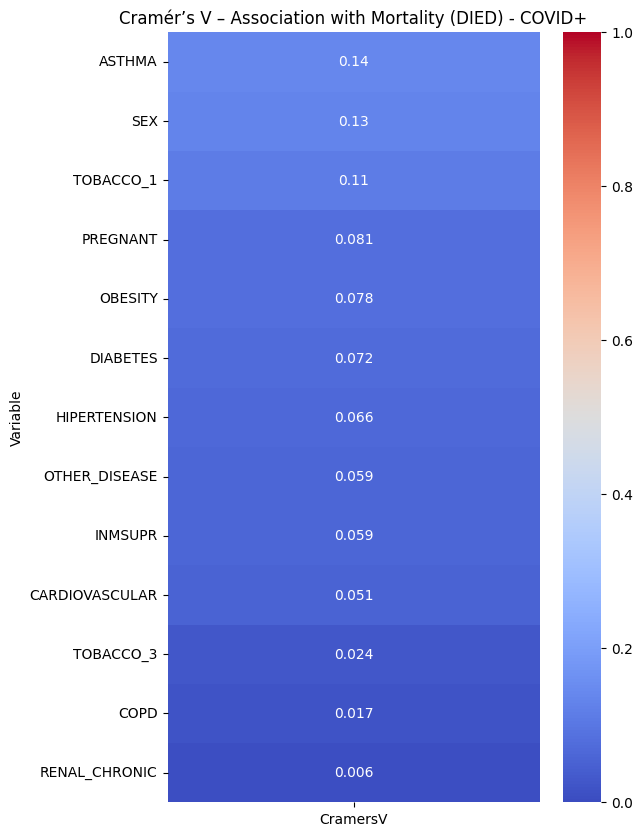

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = cramers_died.set_index('Variable')

plt.figure(figsize=(6,10))
sns.heatmap(heatmap_df, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér’s V – Association with Mortality (DIED) - COVID+")
plt.show()

## 2.4 COVID NEG DATASET

In [97]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

nominal_vars = [
    'SEX','PREGNANT','DIABETES','COPD',
    'ASTHMA','INMSUPR','HIPERTENSION','OTHER_DISEASE','CARDIOVASCULAR',
    'OBESITY','RENAL_CHRONIC','TOBACCO_1', 'TOBACCO_3','COVID_POSITIVE'
]

target = 'DIED'

results = []
for var in nominal_vars:
    ct = pd.crosstab(df_neg[var], df_neg[target])
    if ct.shape[0] > 1 and ct.shape[1] > 1:  
        cv = cramers_v(ct)
        results.append((var, cv))

cramers_died = pd.DataFrame(results, columns=['Variable','CramersV']).sort_values('CramersV', ascending=False)
print(cramers_died)


          Variable  CramersV
4           ASTHMA  0.110306
0              SEX  0.104453
9          OBESITY  0.080052
11       TOBACCO_1  0.073045
2         DIABETES  0.070340
1         PREGNANT  0.055830
6     HIPERTENSION  0.042615
10   RENAL_CHRONIC  0.028160
7    OTHER_DISEASE  0.025263
8   CARDIOVASCULAR  0.023843
5          INMSUPR  0.021300
12       TOBACCO_3  0.003054
3             COPD  0.002385


In [98]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v1(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

nominal_vars = [
   'SEX','PREGNANT','DIABETES','COPD',
    'ASTHMA','INMSUPR','HIPERTENSION','OTHER_DISEASE','CARDIOVASCULAR',
    'OBESITY','RENAL_CHRONIC','TOBACCO_1', 'TOBACCO_3','COVID_POSITIVE', 'DIED'
]

# Matrix
matrixV1 = pd.DataFrame(np.zeros((len(nominal_vars), len(nominal_vars))),
                      index=nominal_vars, columns=nominal_vars)

for col1 in nominal_vars:
    for col2 in nominal_vars:
        ct = pd.crosstab(df_neg[col1], df_neg[col2])
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            matrixV1.loc[col1, col2] = cramers_v1(ct)
        else:
            matrixV1.loc[col1, col2] = 0  


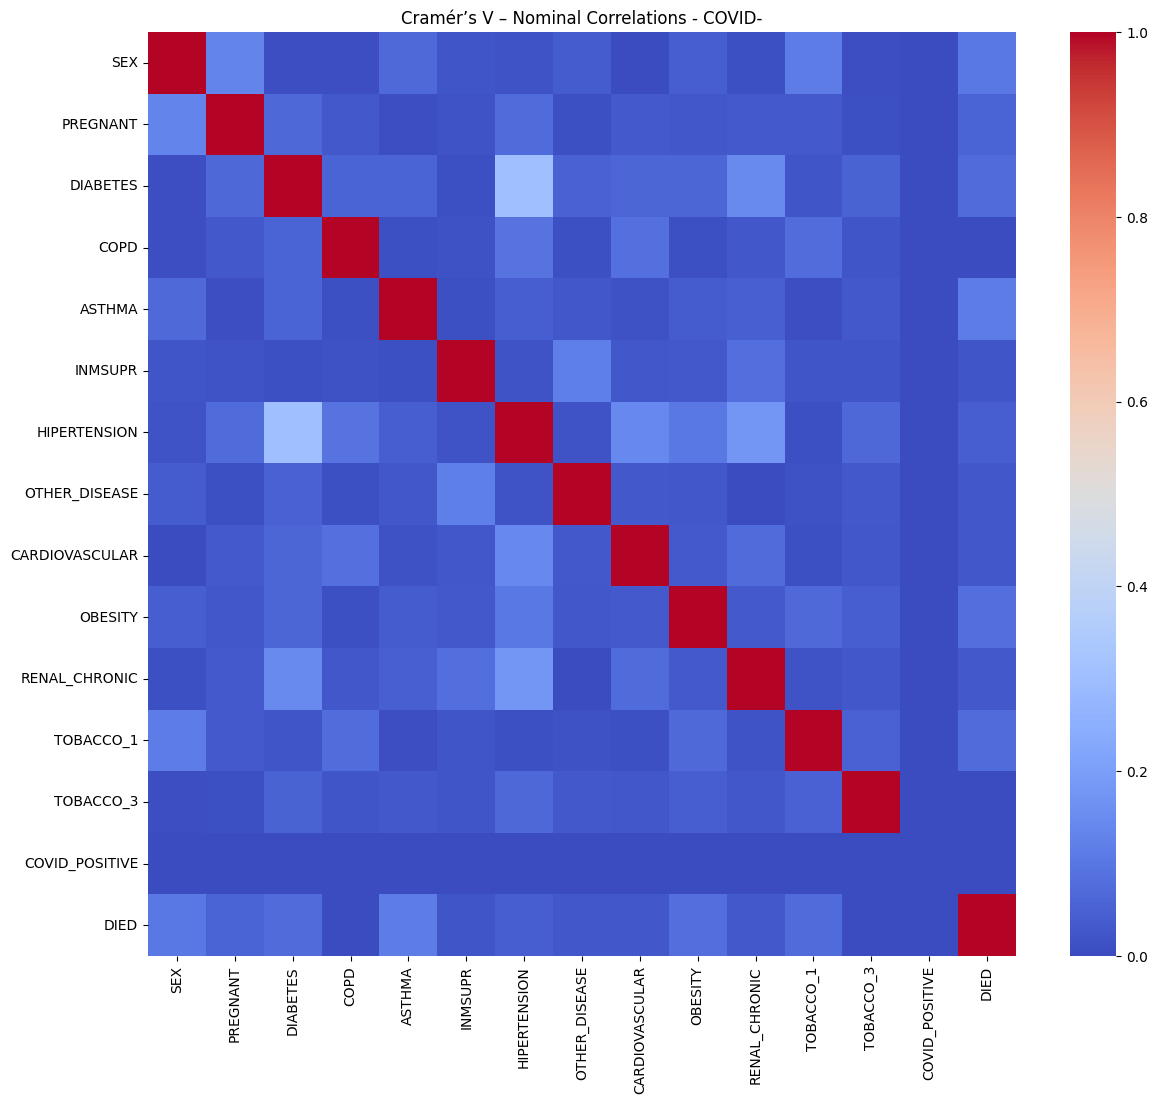

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,12))
sns.heatmap(matrixV1, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér’s V – Nominal Correlations - COVID-")
plt.show()

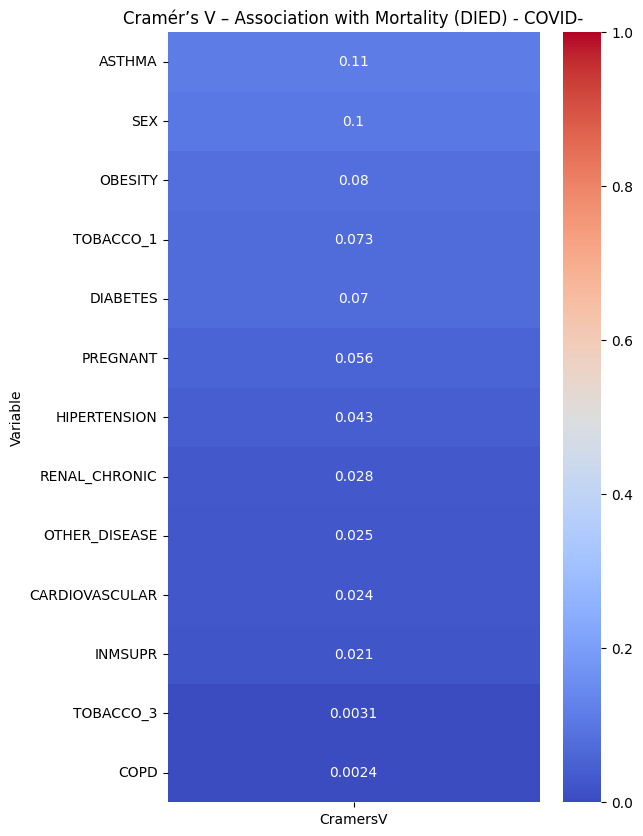

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_df = cramers_died.set_index('Variable')

plt.figure(figsize=(6,10))
sns.heatmap(heatmap_df, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér’s V – Association with Mortality (DIED) - COVID-")
plt.show()

## 2.5 CROSSTAB

In [101]:
ct_covid_died = pd.crosstab(df['COVID_POSITIVE'], df['DIED'])
print("Crosstab COVID_POSITIVE vs. DIED:")
print(ct_covid_died)

cv_covid_died = cramers_v(ct_covid_died)
print(f"\nCramér’s V COVID_POSITIVE vs. DIED: {cv_covid_died}")


Crosstab COVID_POSITIVE vs. DIED:
DIED                1       2
COVID_POSITIVE               
1               53348   59941
2               22617  100624

Cramér’s V COVID_POSITIVE vs. DIED: 0.3074596399116814


COVID‑positive patients show substantially higher mortality. Their risk of death is 2.6 times higher (RR = 2.57), and their odds of death are nearly four times higher (OR = 3.96) compared to COVID‑negative individuals. This aligns with the moderate association seen in Cramér’s V (0.31) and confirms that COVID positivity is a major determinant of mortality in this dataset.

In [83]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from math import sqrt, log, exp

# Crosstab
a = 53348   # COVID_POS=1 & DIED=1
b = 59941  # COVID_POS=1 & DIED=2
c = 22617  # COVID_POS=2 & DIED=1
d = 100624  # COVID_POS=2 & DIED=2

# 2x2 Tabelle
table = np.array([[a, b],
                  [c, d]])

# -----------------------------
# 1. Odds Ratio (OR)
# -----------------------------
OR = (a * d) / (b * c)

# 95%-Konfidenzintervall für OR (log-Skala)
se = sqrt(1/a + 1/b + 1/c + 1/d)
ci_low = exp(log(OR) - 1.96 * se)
ci_high = exp(log(OR) + 1.96 * se)

# -----------------------------
# 2. Relative Risk (RR)
# -----------------------------
risk_pos = a / (a + b)
risk_neg = c / (c + d)
RR = risk_pos / risk_neg

# -----------------------------
# 3. Risk Difference (RD)
# -----------------------------
RD = risk_pos - risk_neg

# -----------------------------
# 4. Chi-Square Test
# -----------------------------
chi2, p, dof, expected = chi2_contingency(table)

# -----------------------------
# 5. Cramér’s V
# -----------------------------
n = table.sum()
cramers_v = sqrt(chi2 / (n * (min(table.shape) - 1)))

# -----------------------------
# 6. Phi-Koeffizient
# -----------------------------
phi = sqrt(chi2 / n)

# -----------------------------
# Ausgabe
# -----------------------------
print(f"Odds Ratio (OR):        {OR}")
print(f"95% CI OR:              ({ci_low}, {ci_high})")
print(f"Relative Risk (RR):     {RR}")
print(f"Risk Difference (RD):   {RD}")
print(f"Chi-Square:             {chi2}")
print(f"p-Wert:                 {p}")
print(f"Cramér’s V:             {cramers_v}")
print(f"Phi:                    {phi}")


Odds Ratio (OR):        3.959685906436609
95% CI OR:              (3.8869076981931263, 4.0338268091422185)
Relative Risk (RR):     2.565964329438134
Risk Difference (RD):   0.28738338084649
Chi-Square:             22359.519179203053
p-Wert:                 0.0
Cramér’s V:             0.3074596399116814
Phi:                    0.3074596399116814


COVID‑positive patients have a substantially higher mortality risk. 
The odds of death are almost 4 times higher in COVID‑positive individuals (OR ≈ 3.96), and their risk of death is about 2.6 times higher (RR ≈ 2.57).
The risk difference of 0.29 indicates that COVID positivity increases absolute mortality risk by nearly 29 percentage points.
The association is highly statistically significant (χ² ≈ 22,360, p < 0.001), confirming that the observed difference is not due to chance.
The effect size measures (Cramér’s V = 0.31, Phi = 0.31) indicate a moderate association, consistent with a clinically meaningful but not deterministic relationship.

# 3. FEATURE SELECTION

We selected only demographic variables (AGE, SEX) and pre‑existing comorbidities as predictors because these represent baseline patient characteristics present before infection. Variables reflecting acute disease severity (INTUBED, ICU, PNEUMONIA, PATIENT_TYPE, MEDICAL_UNIT, USMER) were excluded to avoid information leakage, as they occur after clinical deterioration and would artificially inflate model performance. Variables directly encoding the outcome (DATE_DIED, ID) or the COVID diagnosis itself (COVID_POSITIVE) were also excluded. This ensures that the model predicts mortality based solely on baseline risk factors rather than downstream clinical events.

Label:
DIED

FEATURES:

1. Demografic Variabls

AGE, SEX

2. Comorbidities

DIABETES, OBESITY, HIPERTENSION, CARDIOVASCULAR, COPD, ASTHMA, RENAL_CHRONIC, INMSUPR, OTHER_DISEASE, TOBACCO, PREGNANT  

Excluded:

INTUBED, ICU, PNEUMONIA, PATIENT_TYPE, CLASIFICATION_FINAL, MEDICAL_UNIT, USMER, DATE_DIED, ID, COVID_POSITIVE